# SVM을 사용하여 비만도 계산

In [ ]:
# 무작위로 2만명의 키와 몸무게 데이터를 만들고
# 비만도 계산의 BMI 를 사용해 저체중, 정상, 비만 레이블을 붙이기
# 그리고, 이를 SVM 에 학습시키고, 비만도를 정확하게 맞출수 있는지 테스트

# BMI = kg / (m x m)

# 주제]
#   SVM 사용
#  다중분류 문제에서의 평가지표(metrics)들

## SVM : 서포트 벡터 머신
- support vector machine
- 분류형 모델에서 사용
- 주어진 데이터가 어떤 카테고리에 속할지 판단하는 이진 선형(linear)분류 모델

![](https://img1.daumcdn.net/thumb/R1280x0/?scode=mtistory2&fname=https%3A%2F%2Fblog.kakaocdn.net%2Fdn%2Fbrs4hH%2FbtqwLdV2jMB%2Fak8lLgNQKU2GaR6U9ZEDsk%2Fimg.png)

## Margin 최대화
![](https://img1.daumcdn.net/thumb/R1280x0/?scode=mtistory2&fname=https%3A%2F%2Fblog.kakaocdn.net%2Fdn%2Fbh56rr%2FbtqwJd3vppD%2F958jQaBiONdeq2frzmKbV0%2Fimg.png)

# import

In [1]:
import sklearn
from sklearn import svm, metrics
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import pandas as pd
import random
import os, time
from IPython.display import Image

In [2]:
# 한글 글꼴문제
import matplotlib
from matplotlib import font_manager, rc
import platform

try : 
    if platform.system() == 'Windows':
    # 윈도우인 경우
        font_name = font_manager.FontProperties(fname="c:/Windows/Fonts/malgun.ttf").get_name()
        rc('font', family=font_name)
    else:    
    # Mac 인 경우
        rc('font', family='AppleGothic')
except : 
    pass
matplotlib.rcParams['axes.unicode_minus'] = False   


# 램덤 데이터 만들기
2만명의 키, 몸무게 데이터 생성

In [ ]:
# "키(cm), 몸무게(kg)" -->   "저체중(thin), 정상(normal), 비만(fat)"  출력
# 레이블을 활용해 3개의 컬럼을 갖는 CSV 파일 작성

#### BMI를 계산해서 레이블을 리턴하는 함수

In [3]:
def calc_bmi(h, w):
    bmi = w / (h / 100) ** 2
    if bmi < 18.5: return "thin"
    if bmi < 25: return "normal"
    return "fat"

# 동작 예
calc_bmi(170, 80), calc_bmi(183, 54), calc_bmi(166, 65)    

('fat', 'thin', 'normal')

#### 랜덤 정수 추출  random.randint(from, to)

In [ ]:
random.randint(120, 200)     # 120 ~ 200 사이의 랜덤 정수

## 무작위로 데이터 생성
## 20000 개 데이터 --> CSV 저장

In [4]:
base_path = r'/Users/leo/LeoData/MyCode/KoreaITAcademy/LangChain/dataset'
file_path = os.path.join(base_path, 'bmi.csv')

In [8]:
# 출력파일 준비
with open(file_path, "w", encoding="utf-8-sig") as fp:
    fp.write('height,weight,label\n')

    cnt = {
        "thin": 0,
        "normal": 0,
        "fat": 0,
    }

    random.seed(42)
    for i in range(20000):
        h = random.randint(120, 200)
        w = random.randint(35, 80)
        label = calc_bmi(h, w)
        cnt[label] += 1
        fp.write(f"{h},{w},{label}\n")

    print("✅", cnt)

✅ {'thin': 6347, 'normal': 5991, 'fat': 7662}


# 데이터 읽어 들이기
--> DataFrame 으로

In [9]:
df = pd.read_csv(file_path, encoding='utf-8-sig')
df.head()

,height,weight,label
0,134,36,normal
1,155,50,normal
2,148,43,normal
3,133,78,fat
4,189,40,thin


# 학습전용 데이터와 테스트 전용 데이터 나누기
train_test_split(  데이터, 레이블 )

In [10]:
# 데이터와 레이블(타겟) 분리)

data = df[['height', 'weight']]
label = df['label'].apply(lambda x: {'thin': 0, 'normal': 1, 'fat': 2}[x])

In [11]:
data.head() # 확인

,height,weight
0,134,36
1,155,50
2,148,43
3,133,78
4,189,40


In [12]:
label.head() # 확인

0    1
1    1
2    1
3    2
4    0
Name: label, dtype: int64

In [13]:
# train_test_split 의 X= 에 DataFrame 전달 가능
X_train, X_test, y_train, y_test = \
    train_test_split(data, label, random_state=42)

# X_train, X_test 는 DataFrame
X_train.shape, X_test.shape, y_train.shape, y_test.shape   

((15000, 2), (5000, 2), (15000,), (5000,))

In [14]:
X_train.head() # 확인

,height,weight
5514,140,36
1266,159,45
5864,190,51
15865,194,72
12892,159,59


In [15]:
y_train.head() # 확인

5514     0
1266     0
5864     0
15865    1
12892    1
Name: label, dtype: int64

# 정규화 하기

In [16]:
from sklearn.preprocessing import MinMaxScaler

In [19]:
scaler = MinMaxScaler()
scaler.fit(X_train)
X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [20]:
# 정규화 확인
pd.DataFrame(X_train_scaled, columns=X_train.columns).describe()


,height,weight
count,15000.000000,15000.000000
mean,0.498778,0.501471
std,0.292295,0.296058
min,0.000000,0.000000
25%,0.250000,0.244444
50%,0.500000,0.511111
75%,0.750000,0.755556
max,1.000000,1.000000


# 학습용 (데이터 + 레이블) 로 학습하기
SVC() 사용

In [21]:
# 아래 사용할 clf.fit() 의 표현값을 출력할때 사용하는 내부파일 인코딩과 Windwos 충돌이 발생한다  (2026.8 현재)
# 어떨수 없이 display='text' 로 세팅
sklearn.set_config(display='text')   

In [22]:
clf = svm.SVC()
clf.fit(X_train_scaled, y_train)

SVC()

In [49]:
# train 점수, test 점수 확인
print(clf.score(X_train_scaled, y_train))
print(clf.score(X_test_scaled, y_test))


0.9939333333333333
0.9926


# 예측하기
임의의 데이터 (키, 몸무게) 에 대해서 예측

In [23]:
scaler.feature_names_in_

array(['height', 'weight'], dtype=object)

In [24]:
X_train.columns

Index(['height', 'weight'], dtype='str')

In [28]:
# 예측함수 작성
def predict_bmi(h, w):
    pred = clf.predict(scaler.transform(pd.DataFrame([[h, w]], columns=scaler.feature_names_in_)))
    return pred
    # return {0: "thin", 1: "normal", 2: "fat"}

# 동작 확인
print(
    predict_bmi(162, 89),
    predict_bmi(182, 52),
    predict_bmi(173, 70),
)

[2] [0] [1]


# 평가지표들 확인 metrics
- 성능확인

In [29]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report

In [30]:
predict = clf.predict(X_test_scaled)

In [34]:
print('accuracy', accuracy_score(y_test, predict))
print('precision', precision_score(y_test, predict, average=None))
print('recall', recall_score(y_test, predict, average=None))
print('f1-score', f1_score(y_test, predict, average=None))

accuracy 0.9926
precision [0.98989261 0.9870801  0.99946495]
recall [0.99618563 0.98899676 0.99256111]
f1-score [0.99302915 0.9880375  0.99600107]


## 다중분류에서 여러 값이 나온 이유.

값이 3개씩 나온 이유는 **다중 클래스 분류(Multi-class Classification) 문제에서 각 클래스(레이블)별 지표를 따로 계산하도록 `average=None` 옵션을 지정했기 때문**입니다.

현재 데이터셋의 레이블은 총 3개(`0: thin`, `1: normal`, `2: fat`)로 구성되어 있습니다.

* **배열의 각 인덱스가 의미하는 클래스**
    * `0번째 값`: `thin` (저체중, 클래스 0)의 지표
    * `1번째 값`: `normal` (정상, 클래스 1)의 지표
    * `2번째 값`: `fat` (비만, 클래스 2)의 지표

* **지표별 출력 결과 매칭**
    * **Precision (정밀도)**: 모델이 해당 클래스라고 예측한 것 중 실제 정답인 비율
        * `thin`: 약 98.99%
        * `normal`: 약 98.71%
        * `fat`: 약 99.95%


    * **Recall (재현율)**: 실제 해당 클래스인 데이터 중 모델이 올바르게 맞춘 비율
        * `thin`: 약 99.62%
        * `normal`: 약 98.90%
        * `fat`: 약 99.26%

    * **F1-Score**: Precision과 Recall의 조화평균
        * `thin`: 약 0.9930
        * `normal`: 약 0.9880
        * `fat`: 약 0.9960


3개 클래스의 평균값 하나로 요약해서 확인하고 싶다면, `average` 옵션을 변경하면 됩니다.
* `average='macro'`: 각 클래스별 점수의 단순 산술 평균 (클래스별 가중치 동일)
* `average='weighted'`: 데이터 개수(sample 수)에 비례한 가중 평균



## `classification_report`
분류(Classification) 모델의 예측 성능을 클래스별로 종합 평가하여 텍스트 형태의 보고서로 출력해 주는 함수

In [35]:
cl_report = metrics.classification_report(y_test, predict, target_names=['thin', 'normal', 'fat'])

print("리포트 = \n", cl_report)


리포트 = 
               precision    recall  f1-score   support

        thin       0.99      1.00      0.99      1573
      normal       0.99      0.99      0.99      1545
         fat       1.00      0.99      1.00      1882

    accuracy                           0.99      5000
   macro avg       0.99      0.99      0.99      5000
weighted avg       0.99      0.99      0.99      5000



## roc curve

현재 비만도 분류 모델은 클래스가 3개(`thin`, `normal`, `fat`)인 **다중 분류(Multi-class)** 문제.  

ROC Curve를 그리려면 모델이 **클래스별 예측 확률(Probability)** 또는 결정 점수(Decision Function)를 출력해야 하며, 다중 클래스에서는 각 클래스별 One-vs-Rest(OvR) 방식으로 ROC Curve와 AUC를 계산합니다.


In [37]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn import svm, metrics
from sklearn.preprocessing import label_binarize  # one-hot 인코딩(형태 변환)

/opt/miniconda3/envs/KDT-py/lib/python3.12/site-packages/sklearn/svm/_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(


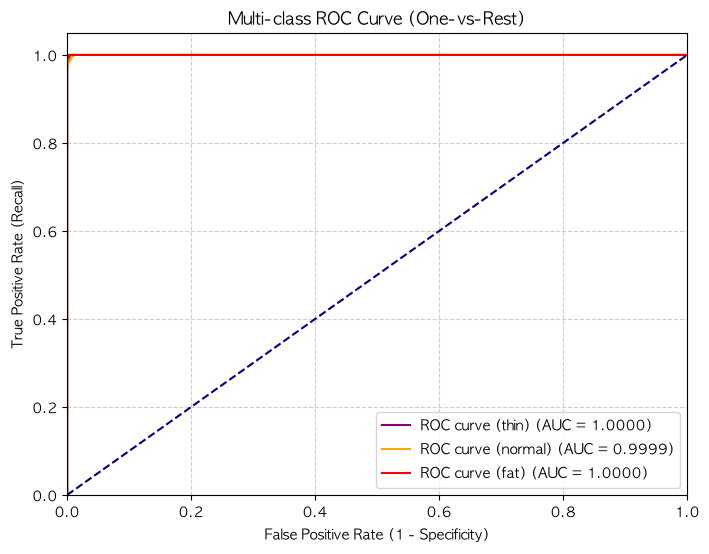

In [42]:
# 1. SVC 모델 생성 시 probability=True 설정 후 재학습 (확률 예측값 추출용)
clf = svm.SVC(probability=True, random_state=42)
clf.fit(X_train_scaled, y_train)

# 2. 테스트 데이터에 대한 각 클래스별 확률값(Probability) 예측
y_score = clf.predict_proba(X_test_scaled)

# 3. 다중 클래스 레이블을 One-Hot Binarize 형태로 변환 (0, 1, 2 -> One-vs-Rest)
classes = [0, 1, 2]
y_test_bin = label_binarize(y_test, classes=classes)

# 4. 각 클래스별 FPR, TPR 및 ROC-AUC 점수 계산
fpr = {}
tpr = {}
roc_auc = {}

for i in range(len(classes)):
    fpr[i], tpr[i], _ = metrics.roc_curve(y_test_bin[:, i], y_score[:, i])
    roc_auc[i] = metrics.auc(fpr[i], tpr[i])

# 5. ROC Curve 시각화
plt.figure(figsize=(8, 6))
colors = ['purple', 'orange', 'red']
class_names = ['thin', 'normal', 'fat']

for i, color in zip(range(len(classes)), colors):
    plt.plot(
        fpr[i], tpr[i],
        color=color, 
        label=f'ROC curve ({class_names[i]}) (AUC = {roc_auc[i]:.4f})'
    )

# 기준 대각선 (랜덤 예측선)
plt.plot([0, 1], [0, 1], color='navy', lw=1.5, linestyle='--')

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (1 - Specificity)')
plt.ylabel('True Positive Rate (Recall)')
plt.title('Multi-class ROC Curve (One-vs-Rest)')
plt.legend(loc="lower right")
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()


# 데이터 분포 시각화

In [43]:
# Pandas 로 CSV 파일 읽어 들이기
df2 = pd.read_csv(file_path, index_col=2, encoding='utf-8-sig')   #index_col  :  3번째 col 인 'label' 을 인덱스로 사용하여 DataFrame 작성
df2.head()  #확인

,height,weight
label,,
normal,134,36
normal,155,50
normal,148,43
fat,133,78
thin,189,40


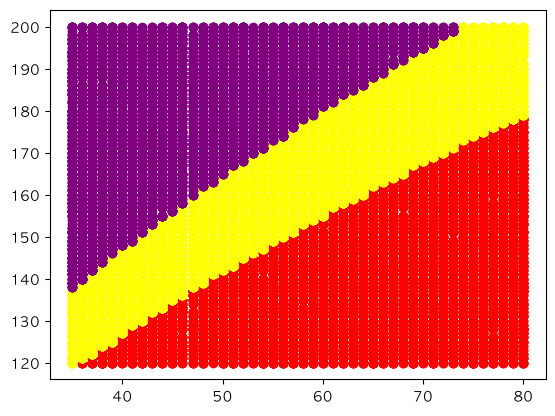

In [48]:
fig, ax = plt.subplots(1, 1)

def scatter(lbl, color):
    b = df2.loc[lbl]
    ax.scatter(b['weight'], b['height'], c=color, label=lbl)

scatter('fat', 'red')
scatter('normal', 'yellow')
scatter('thin', 'purple')

plt.show()

# SVM 의 종류

## SVC / NuSVC / LinearSVC
정밀도와 수행시간 분석해보자

In [ ]:
# SV[M] 이 아니라 SV[C] 인 이유는 Calssification(분류)의 앞글자 사용

In [ ]:
# 실제 해보면
# 정답률은 좀 떨어지지만, 실행시간은 크게 차이남.